In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import MinMaxScaler
small_df = pd.read_parquet('..\\data\\bm\\data_BM01P1_hits.parquet')
small_df = small_df.T

scaler = MinMaxScaler()
small_df = scaler.fit_transform(small_df)

small_df = small_df.T

In [4]:
def plt_bar(idx, x=20):
    plt.bar(range(x), small_df[idx])
    plt.show()

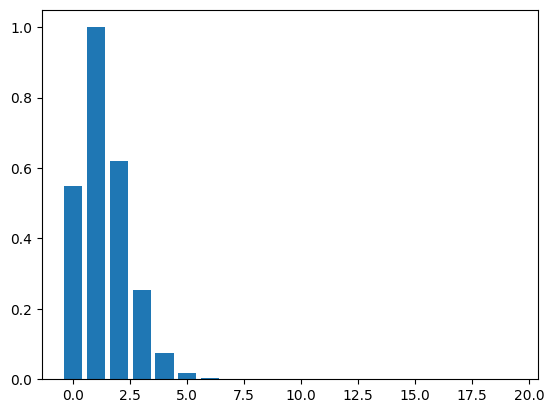

In [5]:
plt_bar(2)

In [6]:
import torch.nn as nn 

# first model
encoder = nn.Sequential(nn.Linear(20, 30), 
                        nn.ReLU(),
                        nn.Linear(30, 40))

decoder = nn.Sequential(nn.Linear(40, 30),
                        nn.ReLU(),
                        nn.Linear(30, 20))

autoenc = nn.Sequential(encoder, decoder)

# second model
encoder_2 = nn.Sequential(nn.Linear(20, 30), 
                        nn.ReLU(),
                        nn.Linear(30, 40),
                        nn.ReLU(),
                        nn.Linear(40, 50),
                        nn.ReLU(),
                        nn.Linear(50, 60),
                        nn.ReLU(),
                        nn.Linear(60, 70),
                        nn.ReLU(),
                        nn.Linear(70, 80),
                        nn.ReLU(),
                        nn.Linear(80, 90))

decoder_2 = nn.Sequential(nn.Linear(90, 60),
                        nn.ReLU(),
                        nn.Linear(60, 20))

autoenc_2 = nn.Sequential(encoder_2, decoder_2)


In [7]:
import torch 

torch_small_df = torch.from_numpy(small_df)
torch_small_df = torch_small_df.to(torch.float32)

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=autoenc.parameters(), lr=0.01)

In [9]:
# first model training loop
losses = []

for pt in torch_small_df:
    autoenc.train()
    recreated = autoenc(pt)
    loss = criterion(recreated, pt)
    loss.backward()
    optimizer.step()
    losses.append(loss.detach().numpy())

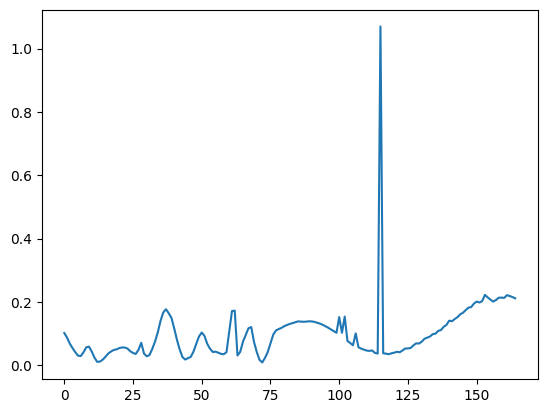

In [10]:
plt.plot(range(len(losses)), losses)

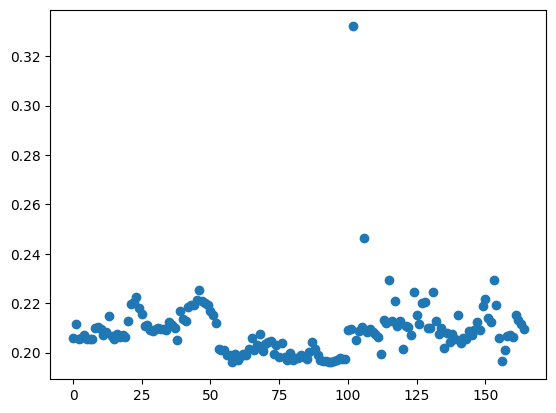

In [11]:
autoenc.eval()
score = []
for pt in torch_small_df:
    loss = criterion(autoenc(pt), pt)
    score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [ ]:
# second model training loop
losses_2 = []
optimizer_2 = torch.optim.Adam(params=autoenc_2.parameters(), lr=0.01)

for i in range(30):
    for pt in torch_small_df:
        autoenc_2.train()
        recreated = autoenc_2(pt)
        loss = criterion(recreated, pt)
        losses_2.append(loss.detach().numpy())
        loss.backward()
        optimizer_2.step()

In [13]:
print(losses_2)

[array(0.09537958, dtype=float32), array(0.07096752, dtype=float32), array(0.04460779, dtype=float32), array(0.02666842, dtype=float32), array(0.06325468, dtype=float32), array(0.02260803, dtype=float32), array(0.00693619, dtype=float32), array(0.02016154, dtype=float32), array(0.0422965, dtype=float32), array(0.05271561, dtype=float32), array(0.05218516, dtype=float32), array(0.04641065, dtype=float32), array(0.04432473, dtype=float32), array(0.0496415, dtype=float32), array(0.05182103, dtype=float32), array(0.06653075, dtype=float32), array(0.08072018, dtype=float32), array(0.08137868, dtype=float32), array(0.06526957, dtype=float32), array(0.04480966, dtype=float32), array(0.3676498, dtype=float32), array(0.02620369, dtype=float32), array(0.02321526, dtype=float32), array(0.02096715, dtype=float32), array(0.01851628, dtype=float32), array(0.016376, dtype=float32), array(0.01530746, dtype=float32), array(0.01465326, dtype=float32), array(0.01608034, dtype=float32), array(0.01991368, 

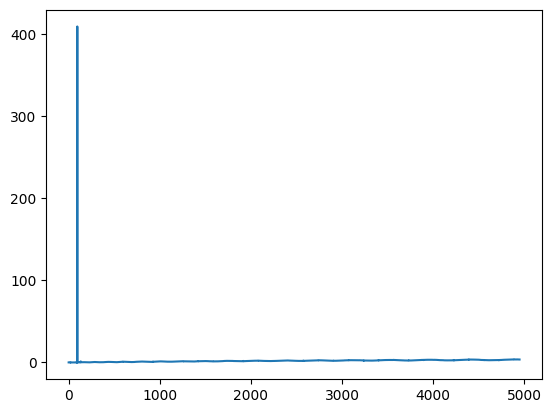

In [14]:
plt.plot(range(len(losses_2)), losses_2)

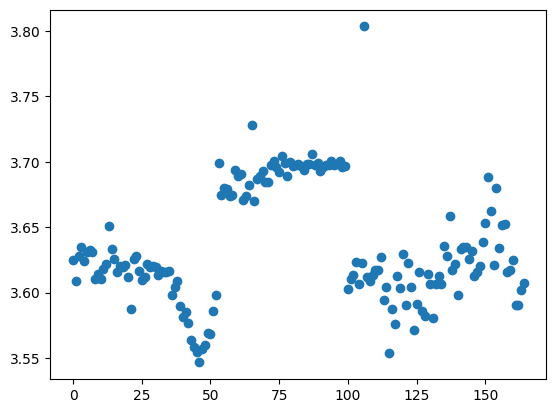

In [15]:
autoenc_2.eval()
score = []
for pt in torch_small_df:
    loss = criterion(autoenc_2(pt), pt)
    score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [16]:
highest = sorted(score)[-5:]
highest_indexes = []
for i in highest:
    highest_indexes.append(score.index(i))

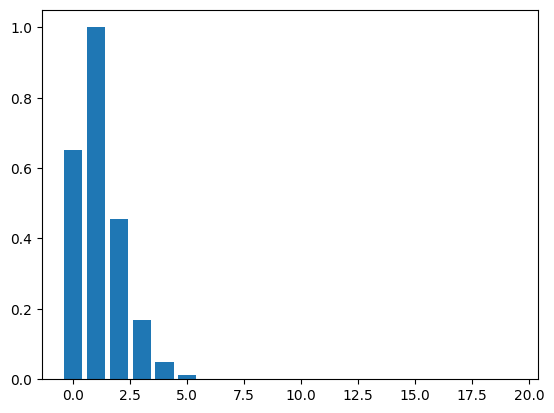

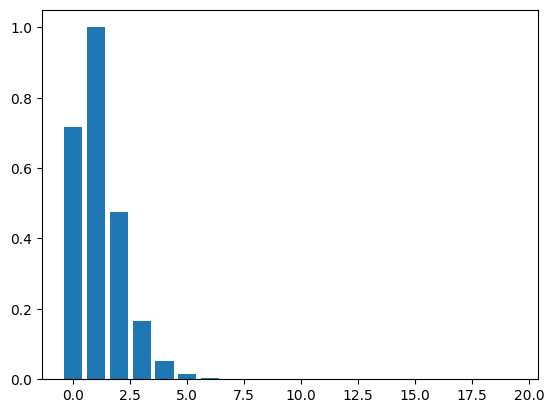

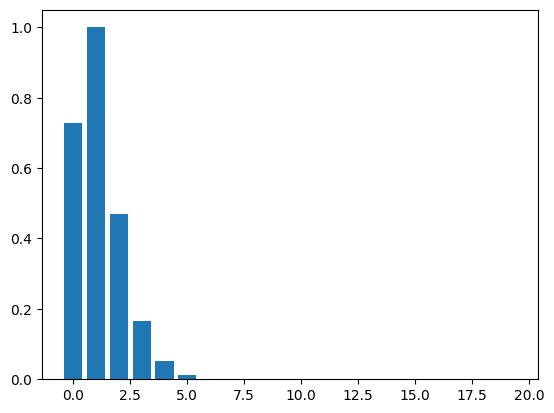

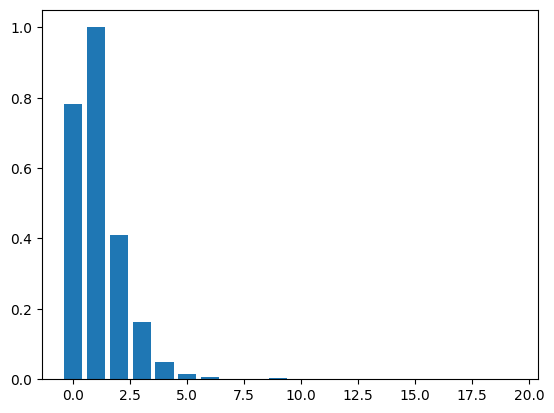

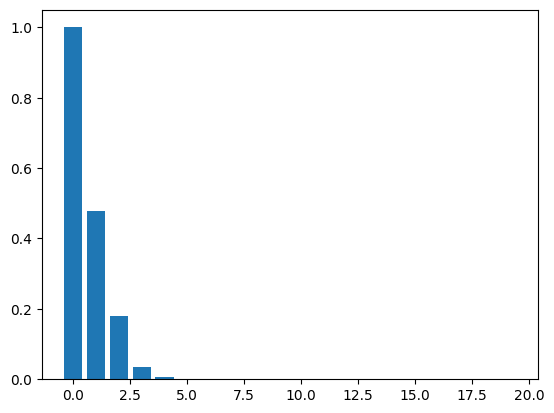

In [17]:
for i in highest_indexes:
    plt.bar(range(len(small_df[i])), small_df[i])
    plt.show()

In [18]:
autoenc_2.eval()
outlier = autoenc_2(torch_small_df[102]).detach().numpy()

In [19]:
save_pt = autoenc_2(torch_small_df[1]).detach().numpy()

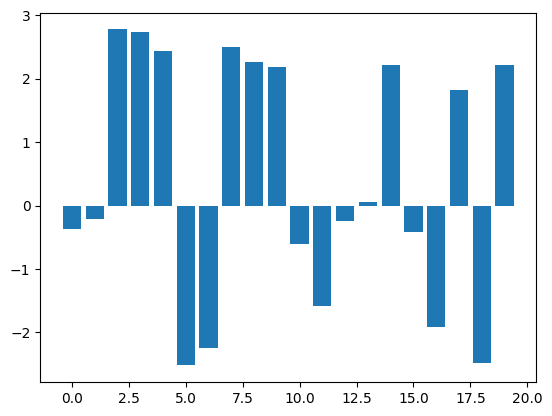

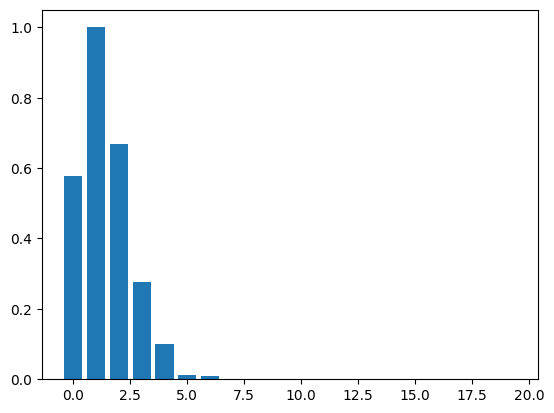

In [20]:
plt.bar(range(len(save_pt)), save_pt)
plt.show()
plt.bar(range(len(torch_small_df[1])), torch_small_df[1])
plt.show()

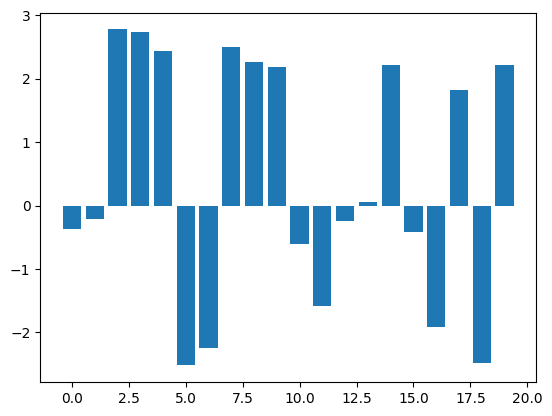

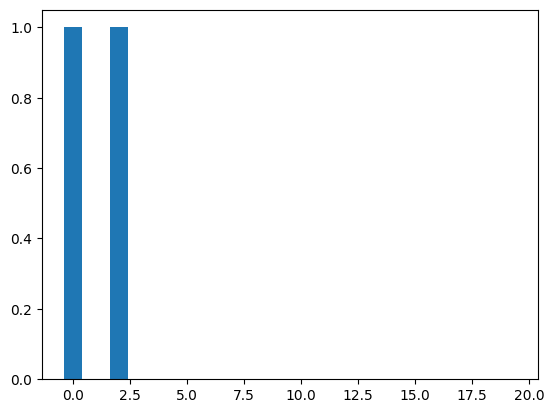

In [21]:
plt.bar(range(len(outlier)), outlier)
plt.show()
plt.bar(range(len(small_df[102])), small_df[102])
plt.show()